# Boosting
### **Principle of Operation**
Boosting, in essence, is about converting weak learners into strong learners. Here's how it achieves this:

- **Sequential Training**: Unlike Bagging methods which involve parallel training, Boosting focuses on sequential training where each model is trained based on the errors of its predecessors.
  
- **Error Correction**: After training a model, Boosting increases the weight of the misclassified instances. This means that the next model in the sequence is more focused on correctly predicting these instances.

- **Final Prediction**:  Once all of the predictors are trained, an aggregate prediction is made based on the performance of individual predictors.


The following example, taken from the book illustrates this idea.  The `learning_rate` parameter here is used to adjust how much we increase the weight of misclassified samples over successive iterations.

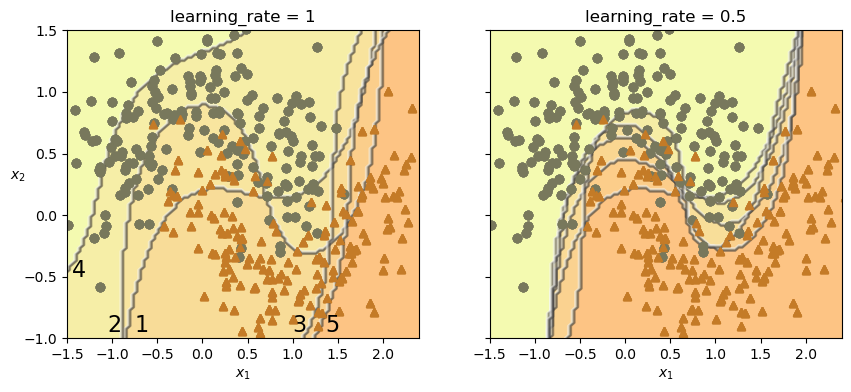

In [1]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(clf, X, y, alpha=1.0):
    axes=[-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

m = len(X_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
for subplot, learning_rate in ((0, 1), (1, 0.5)):
    sample_weights = np.ones(m) / m
    plt.sca(axes[subplot])
    for i in range(5):
        svm_clf = SVC(C=0.2, gamma=0.6, random_state=42)

        # Using SVC's "sample_weights" param - see https://scikit-learn.org/stable/auto_examples/svm/plot_weighted_samples.html
        svm_clf.fit(X_train, y_train, sample_weight=sample_weights * m)
        y_pred = svm_clf.predict(X_train)

        error_weights = sample_weights[y_pred != y_train].sum()

        # Equations refer to the text, chapter 7
        r = error_weights / sample_weights.sum()  # equation 7-1
        alpha = learning_rate * np.log((1 - r) / r)  # equation 7-2
        sample_weights[y_pred != y_train] *= np.exp(alpha)  # equation 7-3
        sample_weights /= sample_weights.sum()  # normalization step

        plot_decision_boundary(svm_clf, X_train, y_train, alpha=0.4)
        plt.title(f"learning_rate = {learning_rate}")
    if subplot == 0:
        plt.text(-0.75, -0.95, "1", fontsize=16)
        plt.text(-1.05, -0.95, "2", fontsize=16)
        plt.text(1.0, -0.95, "3", fontsize=16)
        plt.text(-1.45, -0.5, "4", fontsize=16)
        plt.text(1.36,  -0.95, "5", fontsize=16)
    else:
        plt.ylabel("")

plt.show()


#### **Types of Boosting Algorithms**

**a. AdaBoost** (short for "adaptive boosting")

AdaBoost uses error rates to increase the weights of misclassified instances after each training round, making the next classifier more focused on them. Each predictor is assigned a weight based on its accuracy (or, more specifically, its weighted error rate). Predictors that are more accurate have higher weights, while less accurate predictors have lower weights. For classification problems, the final prediction is made through a weighted vote. Each predictor casts a weighted vote for a class, and the class with the highest total weight across all predictors is chosen as the final prediction. For regression, the predictions of individual predictors can be combined using a weighted average based on the predictor weights.

AdaBoost uses a weighted error rate for the predictor, which can be seen as a form of weighted accuracy, though it focuses on the error rather than the correct predictions.

For a given predictor, the weighted error rate $r$ is calculated as:

  $$r = \frac{\sum_{\text{i=1}}^{m} w_i \times \text{error}_i}{\sum_{\text{i=1}}^{m} w_i}$$

Where:

- $m$ is the number of instances.
- $w_i$ is the weight of the $i^{th}$ instance.
- $\text{error}_i$ is an indicator function, which is $1$ if the $i^{th}$ instance is misclassified and $0$ otherwise.

Basically, $r$ sums up the weights of all the misclassified instances and divides it by the sum of weights of all instances. The closer $r$ is to 0, the better the predictor performed; the closer it is to 1, the worse.

After the error rate $r$ is computed, AdaBoost calculates a weight $\alpha$ for the predictor:

$$\alpha = \eta \times \log{\left(\frac{1 - r}{r}\right)}$$

Where:

- $\eta$ is the learning rate, typically set to 1.

This predictor weight $\alpha$ will determine how much influence this predictor has on the final ensemble prediction. If $r$ is small (meaning the predictor did well), $\alpha$ will be larger, giving the predictor more influence.

Finally, for the instances, AdaBoost updates their weights using:

$$w_i = w_i \times \exp(\alpha \times \text{error}_i)$$

This formula will increase the weights of misclassified instances (where $\text{error}_i = 1$) and leave the weights of correctly classified instances largely unchanged (since $\exp(0) = 1$).



AdaBoost performance: 0.88


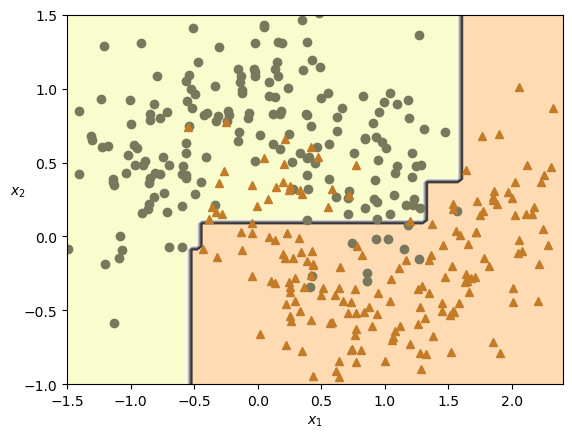

In [2]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=30,
    learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)

y_pred = ada_clf.predict(X_test)
print(f"AdaBoost performance: {accuracy_score(y_test,y_pred)}")


plot_decision_boundary(ada_clf, X_train, y_train)




**b. Gradient Boosting**

Instead of tweaking instance weights like AdaBoost, Gradient Boosting tries to fit the new predictor to the residual errors made by the previous predictor. It's essentially a method of "gradient descent" on the loss function, where each new model attempts to move closer to the optimal model by correcting the residuals of the previous one. It's particularly useful for regression tasks, though it can be adapted for classification as well.  The following offers a deep dive on the how gradient boosting proceeds:


1. **Initialization**
In the following, we use $F_n$ to represent the prediction of the entire ensemble in the $n^{th}$ step. Initialize the model with a constant value, $ F_0 $. This can be, for instance, the mean of the target values for regression:
   $$ F_0(x) = \text{arg min}_{\gamma} \sum_{i=1}^{n} L(y_i, \gamma) $$
   where $ L $ is the loss function. For mean squared error loss, the initial prediction is just the mean of the target values.

2. **Iterative Boosting**
For $ m = 1 $ to $ M $ (where $ M $ is the number of boosting rounds or trees):

   a. **Compute the Pseudo-Residuals**
   Calculate the negative gradient (pseudo-residuals) for each instance, which will act as our "working response":
   $$ r_{im} = - \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x)=F_{m-1}(x)} $$
   For mean squared error loss, this simplifies to:
   $$ r_{im} = y_i - F_{m-1}(x_i) $$

   b. **Fit a Base Learner**
   Train a weak learner (typically a shallow decision tree, but other models can be used) to the pseudo-residuals. This weak learner will try to fit the residuals, rather than the original targets.

   c. **Compute the Multiplier $ \gamma $**
   For a given tree, find the value $ \gamma $ that minimizes the loss when it's added to the existing ensemble. For squared error loss, this can be done using:
   $$ \gamma_m = \text{arg min}_{\gamma} \sum_{i=1}^{n} L \left( y_i, F_{m-1}(x_i) + \gamma h_m(x_i) \right) $$
   where $ h_m(x_i) $ is the prediction of the m-th tree for instance $ x_i $.

   d. **Update the Model**
   Update the ensemble by adding the new model weighted by the multiplier:
   $$ F_m(x) = F_{m-1}(x) + \eta \cdot \gamma_m h_m(x) $$
   where $\eta$ is the learning rate.

3. **Final Model**
The final model is an ensemble of $ M $ trees:
$$ F_M(x) = F_0(x) + \sum_{m=1}^{M} \gamma_m h_m(x) $$

In each iteration, gradient boosting tries to correct the errors made by the previous ensemble, by fitting to the negative gradient of the loss function. The final prediction for a given instance is the sum of the initial prediction and the weighted predictions of all the trees.  Note that Gradient Boosting does not explicitly compute residuals but instead optimizes the loss function using gradient descent. The "pseudo-residuals" provide a direction in which the model should move to reduce the error. By repeatedly adding new models in the direction of the negative gradient, the algorithm gradually improves the ensemble's performance.

### A Worked Example

Let's create a simple quadratic dataset and fit a `DecisionTreeRegressor` to it:

In [3]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)  # y = 3x² + Gaussian noise

tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

Now let's train another decision tree regressor on the residual errors made by the previous predictor:

In [4]:
y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y2)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",43
,"max_leaf

In [5]:
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",44
,"max_leaf

In [6]:
X_new = np.array([[-0.4], [0.], [0.5]])
sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

array([0.49484029, 0.04021166, 0.75026781])

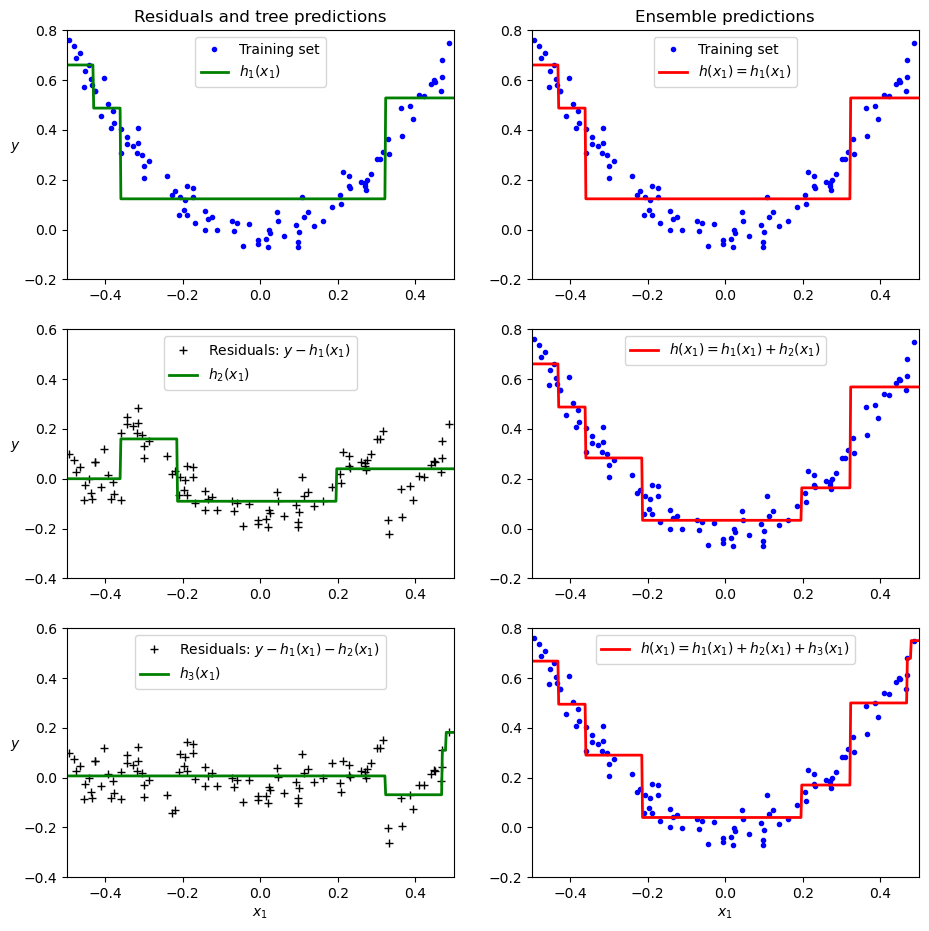

In [7]:
def plot_predictions(regressors, X, y, axes, style,
                     label=None, data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1))
                 for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center")
    plt.axis(axes)

plt.figure(figsize=(11, 11))

plt.subplot(3, 2, 1)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.2, 0.8], style="g-",
                 label="$h_1(x_1)$", data_label="Training set")
plt.ylabel("$y$  ", rotation=0)
plt.title("Residuals and tree predictions")

plt.subplot(3, 2, 2)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.2, 0.8], style="r-",
                 label="$h(x_1) = h_1(x_1)$", data_label="Training set")
plt.title("Ensemble predictions")

plt.subplot(3, 2, 3)
plot_predictions([tree_reg2], X, y2, axes=[-0.5, 0.5, -0.4, 0.6], style="g-",
                 label="$h_2(x_1)$", data_style="k+",
                 data_label="Residuals: $y - h_1(x_1)$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 4)
plot_predictions([tree_reg1, tree_reg2], X, y, axes=[-0.5, 0.5, -0.2, 0.8],
                  style="r-", label="$h(x_1) = h_1(x_1) + h_2(x_1)$")

plt.subplot(3, 2, 5)
plot_predictions([tree_reg3], X, y3, axes=[-0.5, 0.5, -0.4, 0.6], style="g-",
                 label="$h_3(x_1)$", data_style="k+",
                 data_label="Residuals: $y - h_1(x_1) - h_2(x_1)$")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 6)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, y,
                 axes=[-0.5, 0.5, -0.2, 0.8], style="r-",
                 label="$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$")
plt.xlabel("$x_1$")

plt.show()

Now let's try a gradient boosting regressor:

In [8]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3,
                                 learning_rate=1.0, random_state=42)
gbrt.fit(X, y)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",1.0
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",3
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft ch

In [9]:
gbrt_best = GradientBoostingRegressor(
    max_depth=2, learning_rate=0.05, n_estimators=500,
    n_iter_no_change=10, random_state=42)
gbrt_best.fit(X, y)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [11]:
gbrt_best.n_estimators_

92

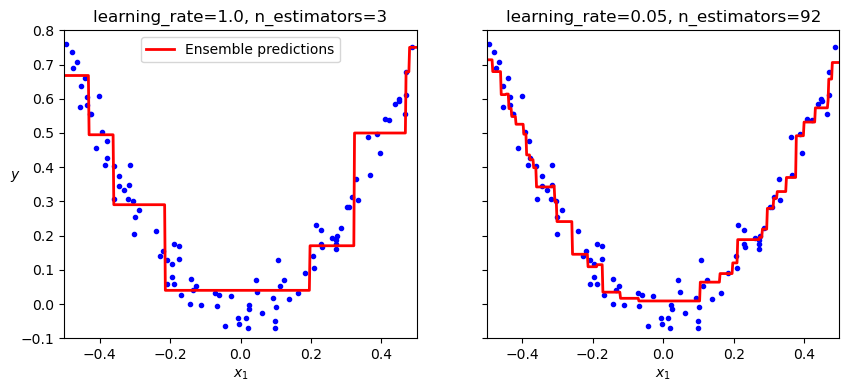

In [12]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plot_predictions([gbrt], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-",
                 label="Ensemble predictions")
plt.title(f"learning_rate={gbrt.learning_rate}, "
          f"n_estimators={gbrt.n_estimators_}")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)

plt.sca(axes[1])
plot_predictions([gbrt_best], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-")
plt.title(f"learning_rate={gbrt_best.learning_rate}, "
          f"n_estimators={gbrt_best.n_estimators_}")
plt.xlabel("$x_1$")
plt.show()

**Learning Rate**

The learning rate plays and important role in boosting, but especially in gradient boosting, as follows:

1. **Regularization**: A smaller learning rate means that the boosting algorithm will be more conservative, making smaller steps. It can prevent overfitting and often leads to a better final model. However, it may require adding more trees to the ensemble to achieve optimal performance, increasing the training time.

2. **Trade-off with Number of Trees**: With a smaller learning rate, you'll typically need more trees in the ensemble to converge to the best solution. Conversely, a larger learning rate may allow the algorithm to converge with fewer trees, but the risk of overshooting the optimal solution (or overfitting to the training data) is higher.

3. **General Rule**: In practice, it's often recommended to set a small learning rate (e.g., 0.01 or 0.1) and then choose the number of trees by using early stopping or cross-validation. This strategy tends to give a robust model with good generalization capabilities.

The introduction of the learning rate is essentially a form of regularization. By forcing the algorithm to take small steps, you're ensuring that no single tree overly corrects the errors of its predecessors, which can help prevent overfitting.

**Loss Function**

The choice of a loss function in Gradient Boosting (and in general) is a crucial aspect of model design. The loss function quantifies how well the model's predictions match the true values, and it provides the feedback necessary to adjust the model during training. Here's some additional detail:

1. **Problem Type**:
    - **Regression**: For regression problems, the most commonly used loss functions are:
      - **Mean Squared Error (MSE)**: Penalizes large deviations more than small ones because of the squaring operation. It's sensitive to outliers.
      - **Mean Absolute Error (MAE)**: Penalizes all errors linearly, so it's less sensitive to outliers compared to MSE.
      - **Huber Loss**: A combination of MSE and MAE. It's quadratic for small errors and linear for large errors, and it's less sensitive to outliers than MSE.
    - **Classification**: For binary classification, the most common is:
      - **Log Loss/Binary Cross-Entropy**: Works well when the output is a probability score between 0 and 1.
    - For multi-class classification:
      - **Multi-class Cross-Entropy**: It's an extension of the binary log loss to multiple classes.

2. **Distribution of Residuals**:
    - If residuals are not normally distributed or if there are outliers, MAE or Huber loss might be preferable over MSE, as they are more robust to outliers.

3. **Domain Knowledge**:
    - If we have a fixed domain and we care about errors more in certain regions of the domain (like the extremes), then a custom loss function might be necessary. A custom loss function would penalize errors in those regions more heavily.

4. **Computational Considerations**:
    - While MAE is robust to outliers, it's not differentiable at zero, which can pose challenges during optimization. The Huber loss is a good alternative that combines the best of both MSE and MAE and is differentiable everywhere.
    - MSE, being quadratic, has a unique minimum which can make optimization more straightforward.

5. **Interpretability**:
    - MSE is widely used and understood, so models optimized with MSE might be more easily interpretable by a broader audience.

6. **Performance at Extrema**:
    - Certain loss functions like MSE might lead to reduced performance at extrema, especially if the training data doesn't have enough representation at those extremes. This is because the squared term in MSE will tend to pull predictions towards the mean. If extreme values are critical, using a loss function like MAE or even designing a custom loss function that penalizes errors at the extremes more heavily can be beneficial.



**c. XGBoost** (Extreme gradient boosting)

XGBoost is an optimized and scalable implementation of gradient boosting. Over the years, XGBoost has become a dominant algorithm in machine learning competitions and real-world applications due to its performance and predictive power. XGBoost is built upon the principles of Gradient Boosting, but it incorporates a regularized model formalization to control overfitting, which gives it better performance.

1. **Regularization**:
    - While traditional Gradient Boosting only has a loss function, XGBoost adds regularization to the objective function. This regularization (L1 - Lasso Regression and L2 - Ridge Regression) helps in preventing over-fitting.
      - **NOTE**: L1 and L2 regression are penalties that are applied to the loss function that encourage a learner to find fewer (L1) or smaller (L2) parameters.  

2. **Parallel Processing**:
    - One of the reasons XGBoost is "extreme" is its ability to parallelize the construction of trees during training. While boosting is inherently sequential (you have to build one tree at a time), you can parallelize the building of each tree, making XGBoost faster than many other implementations of gradient boosting.

3. **Handling Missing Values**:
    - XGBoost can automatically handle missing data points. During training, the model learns the best imputation value for the missing values based on reduction in the loss.

4. **Tree Pruning**:
    - Unlike Gradient Boosting, which stops splitting a node once a negative loss is encountered, XGBoost grows the tree to its maximum depth and then prunes it backward to remove the non-positive splits.

5. **Built-in Cross-Validation**:
    - XGBoost supports built-in cross-validation at each iteration of the boosting process, allowing for the easy tracking of the performance of the model.

6. **Flexibility**:
    - XGBoost allows users to define custom optimization objectives and evaluation criteria, making it adaptable to various problems.

7. **Dart Booster**:
    - Implements Dropouts in boosting, which can make the model more robust by adding a form of regularization.


**Hyperparameters**:

Some of the essential hyperparameters in XGBoost include:
- **learning_rate (or eta)**: Determines the step size at each iteration while moving towards a minimum of the loss function.
- **max_depth**: Maximum depth of the decision tree.
- **subsample**: Fraction of the training data to be used for training each tree.
- **colsample_bytree**: Fraction of features to be used for constructing each tree.
- **n_estimators**: Number of boosting rounds.
- **objective**: Specifies the learning task and the corresponding objective function like 'reg:squarederror' for regression tasks and 'binary:logistic' for binary classification.
- **booster**: The type of boosting model to use, including 'gbtree' (tree-based models), 'gblinear' (linear models), and 'dart' (Dropouts meet Multiple Additive Regression Trees).

**Using XGBoost in Scikit-Learn**:

XGBoost is not part of Scikit-Learn, but provides a Scikit-Learn compatible API you can use just like any other Scikit-Learn estimator:

```python
import xgboost as xgb

# Regression
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)

# Classification
xg_clf = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100)

xg_reg.fit(X_train, y_train)
preds = xg_reg.predict(X_test)
```

Remember, tuning the hyperparameters is key to getting the best performance out of XGBoost.

#### Worked Example and Exercise

For this example, we'll try manually tuning hyperparameters to improve performance with XGBoost.


In [13]:
# You'll need to install xgboost if you don't have it
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   --- ------------------------------------ 8.9/101.7 MB 55.5 MB/s eta 0:00:02
   ---------- ----------------------------- 26.2/101.7 MB 69.2 MB/s eta 0:00:02
   ---------------- ----------------------- 41.4/101.7 MB 71.2 MB/s eta 0:00:01
   ---------------------- ----------------- 57.9/101.7 MB 72.4 MB/s eta 0:00:01
   ----------------------------- ---------- 75.5/101.7 MB 74.1 MB/s eta 0:00:01
   ---------------------------------- ----- 88.3/101.7 MB 71.4 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 71.2 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 71.2 MB/s eta 0:00:01
   --------------------------------------- 101.7/101.7 MB 53.2 MB/s eta 0:00:00


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import xgboost as xgb
from xgboost import plot_importance

data = load_wine()

# We'll use a data frame to make sure we get real feature names out
X = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = xgb.XGBClassifier(objective='multi:softprob', random_state=42)
clf.fit(X_train, y_train)

baseline_accuracy = clf.score(X_test, y_test)
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.9444


Note that XGBoost comes with a nice method for visualizing feature importance.

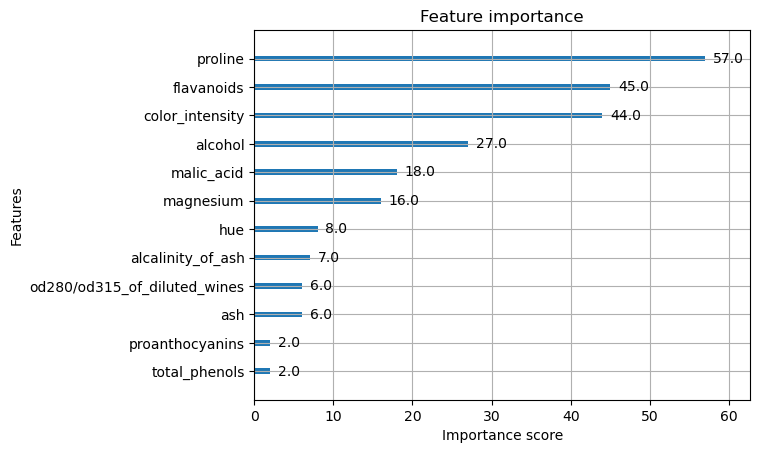

In [16]:
plot_importance(clf)
plt.show()

#### Exercise

Manually tune the hyperparameters of the XGBoost model to try to achieve better accuracy on the test set than the baseline model. Some hyperparameters to consider tweaking:
   - `learning_rate`
   - `max_depth`
   - `n_estimators`
   - `gamma`
   - `subsample`
   - `colsample_bytree`

See [the online docs](https://xgboost.readthedocs.io/en/stable/parameter.html) for more info.

After tuning, use the `plot_importance` function again to see if feature importances have changed after tuning.


1. How did hyperparameter tuning affect the model's accuracy? Which hyperparameters seemed to have the most influence?
2. Did feature importances change after tuning? If so, why might that be?

### **Summary: Bagging vs. Boosting**

Both bagging and boosting improve the performance of models by combining multiple learners. However, they employ distinct strategies to achieve this goal.

#### **Bagging**

**Key Idea**: Create multiple subsets of the original dataset using bootstrap sampling and train a base learner on each subset. Combine their outputs for the final prediction.

**Examples**: Random Forests, Bagged Decision Trees

**Advantages**:
- **Reduces Variance**: Especially useful for algorithms that are sensitive to the specific data they are trained on (like decision trees). By averaging out the results, bagging helps to reduce overfitting.
  
- **Parallelism**: Each model is trained independently, allowing for parallel processing.
  
- **Out-of-Bag Evaluation**: Since each sample might not see some of the training data (around 37% on average), this unused data can be used for validation, called out-of-bag evaluation.

**When to use**:
- When the individual models have high variance (e.g., deep decision trees).
- When you have computational resources to train models in parallel.

#### **Boosting**

**Key Idea**: Train models sequentially, with each model trying to correct the mistakes of its predecessor.

**Examples**: AdaBoost, Gradient Boosting, XGBoost

**Advantages**:
- **Reduces Bias and Variance**: Boosting can capture complex non-linear patterns. By focusing on mistakes, it often results in higher accuracy than bagging.
  
- **Weighted Training**: Boosting assigns weights to training instances, placing more emphasis on those that were misclassified.
  
- **Model Simplicity**: Typically, weak learners (like shallow trees) are used, which are fast to train.

**When to use**:
- When the individual model is weak, and there's a need to boost its accuracy.
- When model interpretability is not a primary concern (boosted models can become complex).


#### **Which to Choose?**

- **Nature of Data & Problem**: If your model is overfitting, bagging is often a good choice. If it's underfitting, boosting might be more suitable.
  
- **Computational Resources**: Bagging can exploit parallelism, so if you have the resources, it can be faster than sequential boosting.
  
- **Model Complexity**: Boosting might result in a more complex model. If interpretability is essential, consider this trade-off.

- **Performance**: Often, in practice, it's beneficial to try both and validate based on performance metrics suitable for the problem at hand.